# 4a. Adaptation Analysis

**Purpose**: Characterise how animals adapt when the stimulus distribution
shifts. This is the central scientific question — PPC is hypothesised to
be necessary when the internal statistical model is inadequate.

**Protocol**:
1. Detect distribution shifts in each animal's timeline
2. Split sessions into baseline (expert Uniform) and post-shift phases
3. Compute adaptation trajectories (session-by-session stats)
4. Fit recovery curves (exponential convergence)
5. Statistical comparison: baseline vs early-post vs late-post
6. Quantify shift magnitude and convergence speed
7. Aggregate across animals

**Paradigm**: Uniform → Hard-A → Hard-B → Hard-A (if time permits)

Each transition provides a different test:
- Uniform → Hard-A: first novel shift
- Hard-A → Hard-B: shift with meta-experience
- Hard-B → Hard-A: return to familiar distribution

In [1]:
import sys, os
sys.path.append(os.path.abspath('..'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

%matplotlib inline
plt.rcParams['figure.dpi'] = 120

In [2]:
from pathlib import Path

from behav_utils.data.loading import load_experiment
from behav_utils.data.selection import select_sessions
from behav_utils.plotting.styles import COLOURS, apply_style
from behav_utils.plotting.update_matrix import plot_update_matrix
from behav_utils.analysis.update_matrix import compute_update_matrix, matrix_error

from analysis.adaptation import (
    detect_all_manipulations,
    detect_first_manipulation,
    adaptation_trajectory,
    fit_recovery_curve,
    compare_phases,
    compute_shift_magnitude,
    compute_convergence_metrics,
    classify_sessions,
    aggregate_trajectories,
)

from behav_utils.analysis.update_matrix import compute_update_matrix_from_sessions
from behav_utils.plotting.update_matrix import plot_phase_update_matrices
from behav_utils.plotting.psychometric import plot_psychometric_overlay

apply_style()
print('Imports OK')

Imports OK


## 1. Configuration

In [3]:
CONFIG_PATH = Path('../config.yaml')
STAGE = 'Full_Task_Cont'

# Baseline selection criteria (expert Uniform)
BASELINE_MIN_ACCURACY = 0.70
BASELINE_LAST_FRACTION = 0.50

# Stats to track across the shift
TRACK_STATS = ['accuracy', 'pse', 'slope', 'recency', 'side_bias', 'choice_entropy']

# Phase comparison windows
EARLY_POST_SESSIONS = 5   # first N post-shift sessions
LATE_POST_SESSIONS = 5    # last N post-shift sessions

## 2. Load Data & Detect Shifts

In [4]:
experiment = load_experiment(CONFIG_PATH)
print(f"Loaded {len(experiment.animal_ids)} animals")

# Detect all manipulations across all animals
shift_info = {}  # animal_id -> list of manipulation dicts

for aid in experiment.animal_ids:
    animal = experiment.get_animal(aid)
    manips = detect_all_manipulations(animal, stage=STAGE)
    if manips:
        shift_info[aid] = manips
        for m in manips:
            print(f"  {aid}: {m['type']} at session {m['global_session_idx']} "
                  f"({m['details']})")
    else:
        print(f"  {aid}: no manipulation detected")

animals_with_shifts = list(shift_info.keys())
print(f"\n{len(animals_with_shifts)} animals with distribution shifts")

Loaded 12 animals, 433 total sessions
Loaded 12 animals
  SS01: distribution_shift at session 44 ({'before': 'Uniform', 'after': 'Hard-B'})
  SS02: no manipulation detected
  SS04: distribution_shift at session 56 ({'before': 'Uniform', 'after': 'Hard-B'})
  SS05: distribution_shift at session 34 ({'before': 'Uniform', 'after': 'Hard-B'})
  SS06: distribution_shift at session 34 ({'before': 'Uniform', 'after': 'Hard-B'})
  SS07: distribution_shift at session 34 ({'before': 'Uniform', 'after': 'Hard-B'})
  SS08: distribution_shift at session 34 ({'before': 'Uniform', 'after': 'Hard-B'})
  SS08: distribution_shift at session 35 ({'before': 'Hard-B', 'after': 'Uniform'})
  SS08: distribution_shift at session 37 ({'before': 'Uniform', 'after': 'Hard-B'})
  SS08: distribution_shift at session 38 ({'before': 'Hard-B', 'after': 'Uniform'})
  SS08: distribution_shift at session 39 ({'before': 'Uniform', 'after': 'Hard-B'})
  SS08: distribution_shift at session 40 ({'before': 'Hard-B', 'after':

## 3. Per-Animal Adaptation Analysis

For each animal with a shift:
- Baseline = expert Uniform sessions before the shift
- Post = all sessions after the shift
- Compute trajectory, recovery curve, phase comparison

In [5]:
per_animal_results = {}  # animal_id -> dict of results

for aid in animals_with_shifts:
    animal = experiment.get_animal(aid)
    manips = shift_info[aid]
    first_shift = manips[0]
    shift_idx = first_shift['session_idx']  # index within stage-filtered sessions

    # Get all sessions for this stage
    all_sessions = animal.get_sessions(stage=STAGE)

    # Baseline: expert Uniform sessions before the shift
    pre_sessions = all_sessions[:shift_idx]
    baseline = select_sessions(
        animal,
        stage=STAGE,
        distribution='Uniform',
        min_accuracy=BASELINE_MIN_ACCURACY,
        last_fraction=BASELINE_LAST_FRACTION,
    )
    # Only keep baseline sessions that are actually before the shift
    baseline = [s for s in baseline if s.session_idx < all_sessions[shift_idx].session_idx]

    # Post: all sessions after the shift
    post = all_sessions[shift_idx:]

    if len(baseline) < 3 or len(post) < 3:
        print(f"  {aid}: insufficient sessions "
              f"(baseline={len(baseline)}, post={len(post)}), skipping")
        continue

    print(f"\n{'='*60}")
    print(f"  {aid}: {first_shift['details']}")
    print(f"  Baseline: {len(baseline)} sessions, Post: {len(post)} sessions")

    # ── Trajectory ──────────────────────────────────────────────────────────
    traj = adaptation_trajectory(baseline, post, stats=TRACK_STATS)

    # ── Recovery curves ─────────────────────────────────────────────────────
    recovery = {}
    for stat in TRACK_STATS:
        recovery[stat] = fit_recovery_curve(baseline, post, stat=stat)

    # ── Convergence metrics ─────────────────────────────────────────────────
    convergence = compute_convergence_metrics(baseline, post, stats=TRACK_STATS)

    # ── Phase comparison ────────────────────────────────────────────────────
    early_post = post[:EARLY_POST_SESSIONS]
    late_post = post[-LATE_POST_SESSIONS:] if len(post) >= LATE_POST_SESSIONS else post

    comp_early = compare_phases(
        baseline, early_post, stats=TRACK_STATS, test='mannwhitneyu',
    )
    comp_late = compare_phases(
        baseline, late_post, stats=TRACK_STATS, test='mannwhitneyu',
    )

    # ── Shift magnitude ─────────────────────────────────────────────────────
    acc_drop = compute_shift_magnitude(baseline, post, metric='accuracy_drop')
    pse_shift = compute_shift_magnitude(baseline, post, metric='pse_shift')

    # ── State classification ────────────────────────────────────────────────
    labels = classify_sessions(baseline, post, stats=TRACK_STATS)

    per_animal_results[aid] = {
        'shift': first_shift,
        'baseline': baseline,
        'post': post,
        'trajectory': traj,
        'recovery': recovery,
        'convergence': convergence,
        'comp_early': comp_early,
        'comp_late': comp_late,
        'acc_drop': acc_drop,
        'pse_shift': pse_shift,
        'labels': labels,
    }

    # ── Print summary ───────────────────────────────────────────────────────
    print(f"  Accuracy drop: {acc_drop['value']:.3f} "
          f"(baseline={acc_drop['baseline_mean']:.3f}, "
          f"early post={acc_drop['post_mean']:.3f})")
    print(f"  PSE shift: {pse_shift['value']:.3f}")

    # Recovery speed
    acc_rec = recovery['accuracy']
    if acc_rec['converged']:
        print(f"  Accuracy recovery: tau={acc_rec['tau']:.1f} sessions, "
              f"R²={acc_rec['r_squared']:.2f}")
    else:
        print(f"  Accuracy recovery: fit did not converge")

    ttc = acc_rec.get('sessions_to_criterion', np.nan)
    print(f"  Sessions to criterion (1 SD): {ttc}")

    # Classification
    n_updating = labels.count('updating')
    print(f"  State labels: {n_updating}/{len(labels)} 'updating'")

print(f"\n{'='*60}")
print(f"Analysed {len(per_animal_results)} animals")


  SS01: {'before': 'Uniform', 'after': 'Hard-B'}
  Baseline: 11 sessions, Post: 7 sessions
  Accuracy drop: 0.150 (baseline=0.727, early post=0.577)
  PSE shift: 0.483
  Accuracy recovery: tau=1.2 sessions, R²=0.49
  Sessions to criterion (1 SD): nan
  State labels: 7/7 'updating'

  SS04: {'before': 'Uniform', 'after': 'Hard-B'}
  Baseline: 23 sessions, Post: 7 sessions
  Accuracy drop: 0.017 (baseline=0.796, early post=0.778)
  PSE shift: -0.332
  Accuracy recovery: tau=4.9 sessions, R²=0.56
  Sessions to criterion (1 SD): 1
  State labels: 2/7 'updating'

  SS05: {'before': 'Uniform', 'after': 'Hard-B'}
  Baseline: 9 sessions, Post: 7 sessions
  Accuracy drop: 0.130 (baseline=0.739, early post=0.610)
  PSE shift: 0.525
  Accuracy recovery: tau=1.1 sessions, R²=0.49
  Sessions to criterion (1 SD): nan
  State labels: 7/7 'updating'

  SS06: {'before': 'Uniform', 'after': 'Hard-B'}
  Baseline: 12 sessions, Post: 7 sessions
  Accuracy drop: 0.079 (baseline=0.762, early post=0.683)
  P

## 4. Adaptation Trajectories — Per Animal

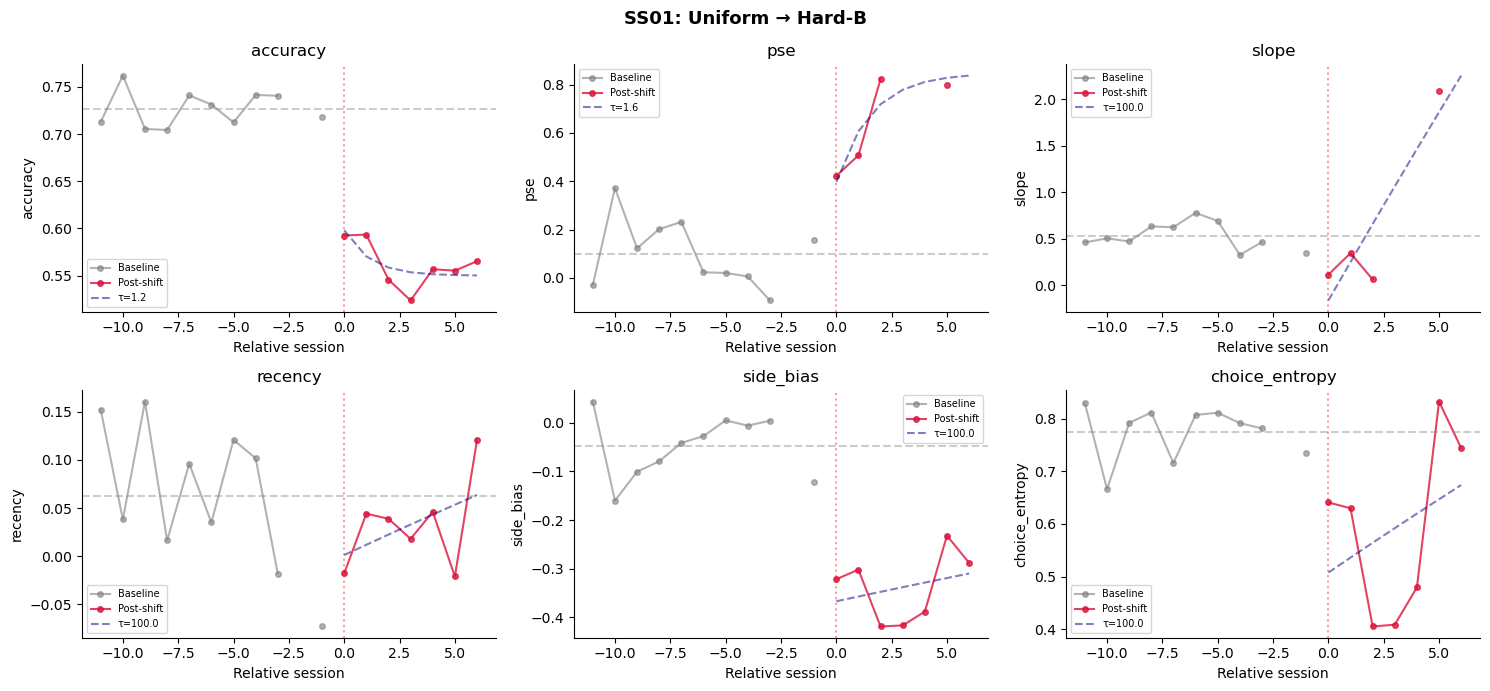

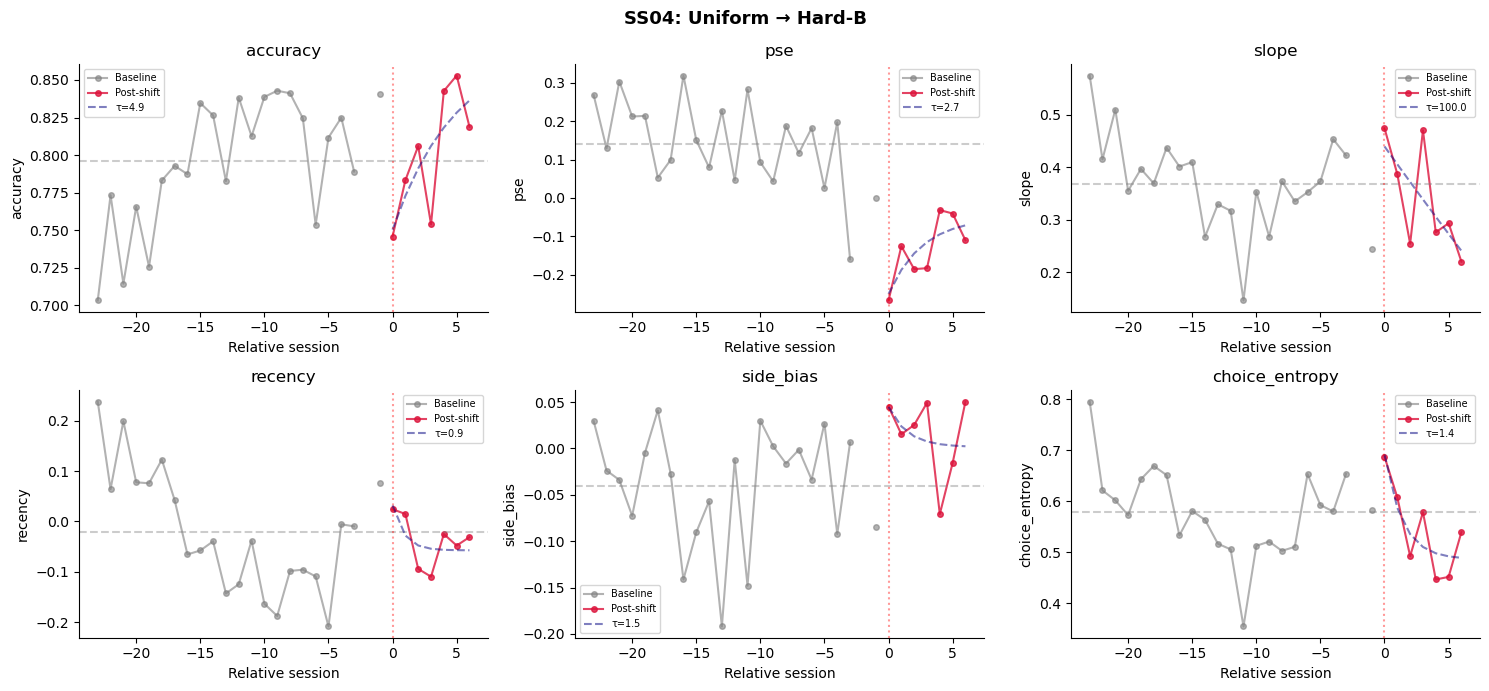

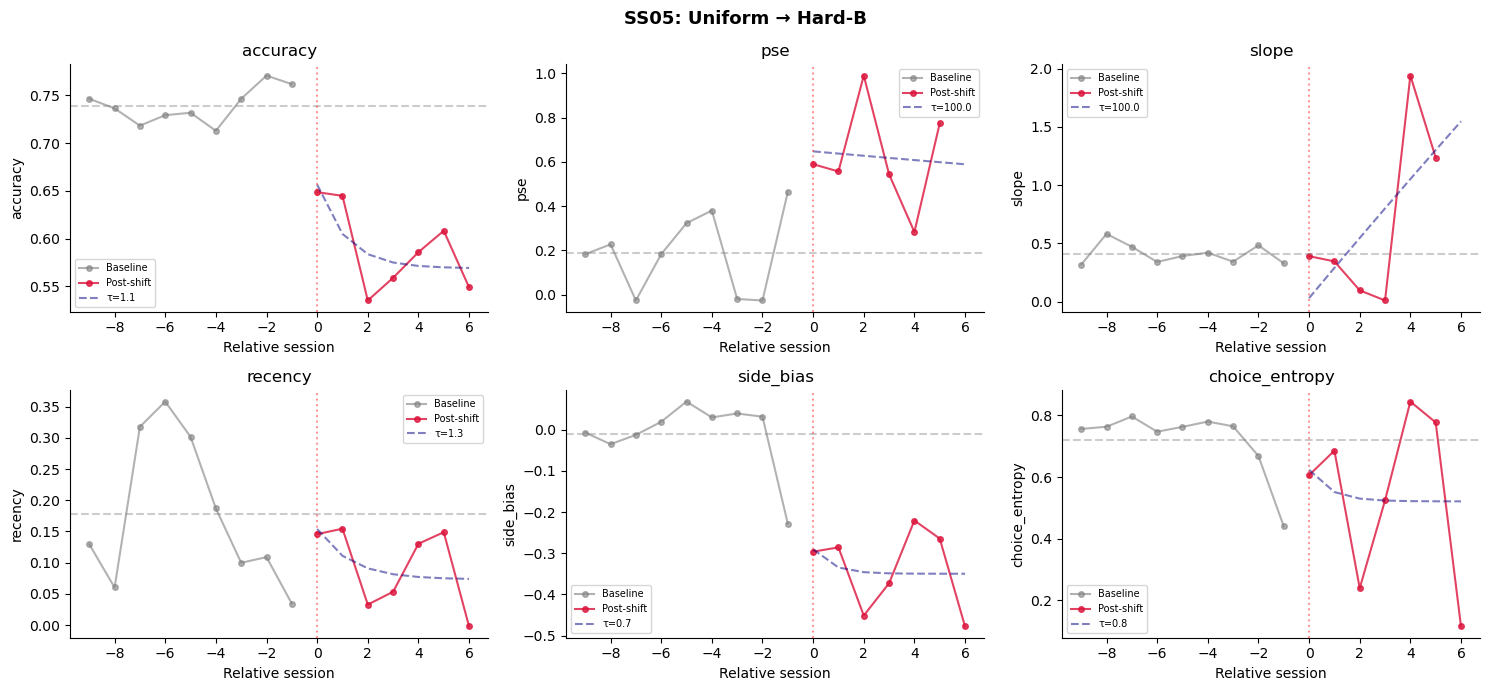

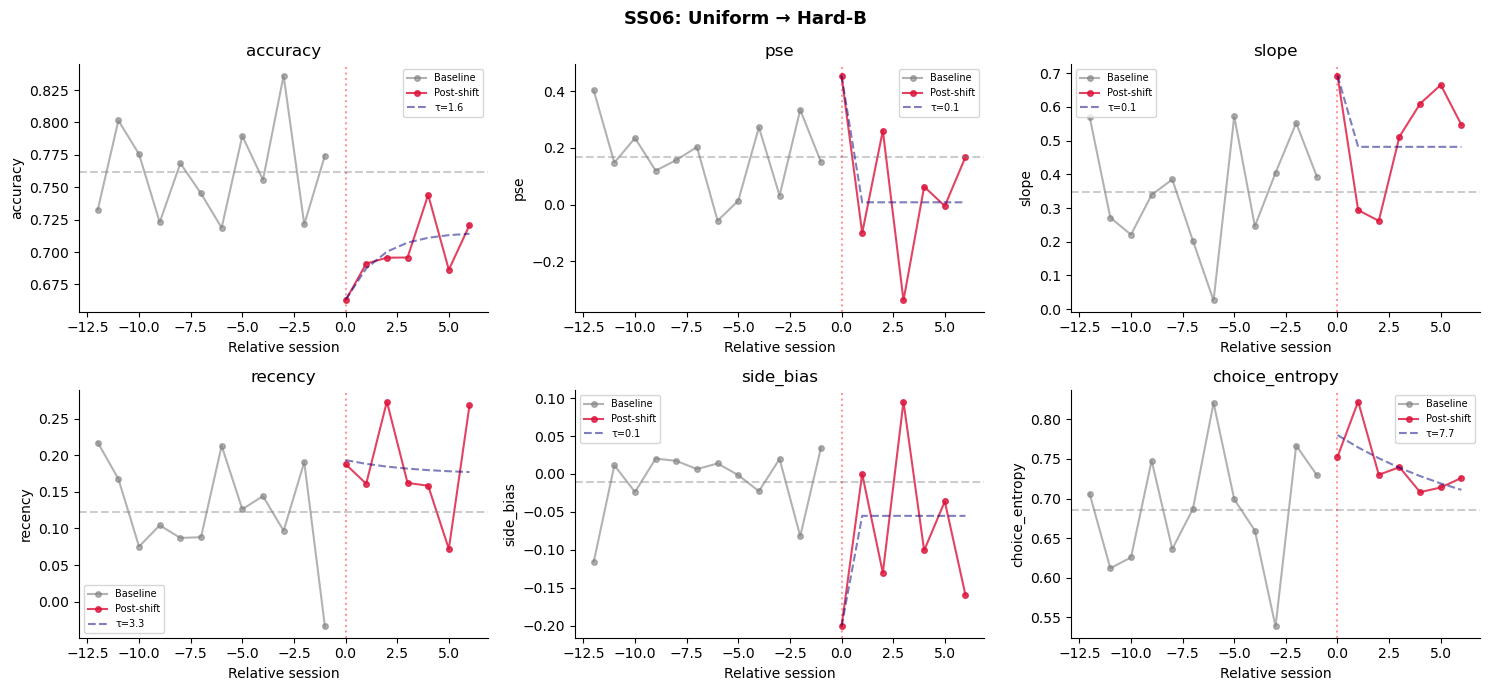

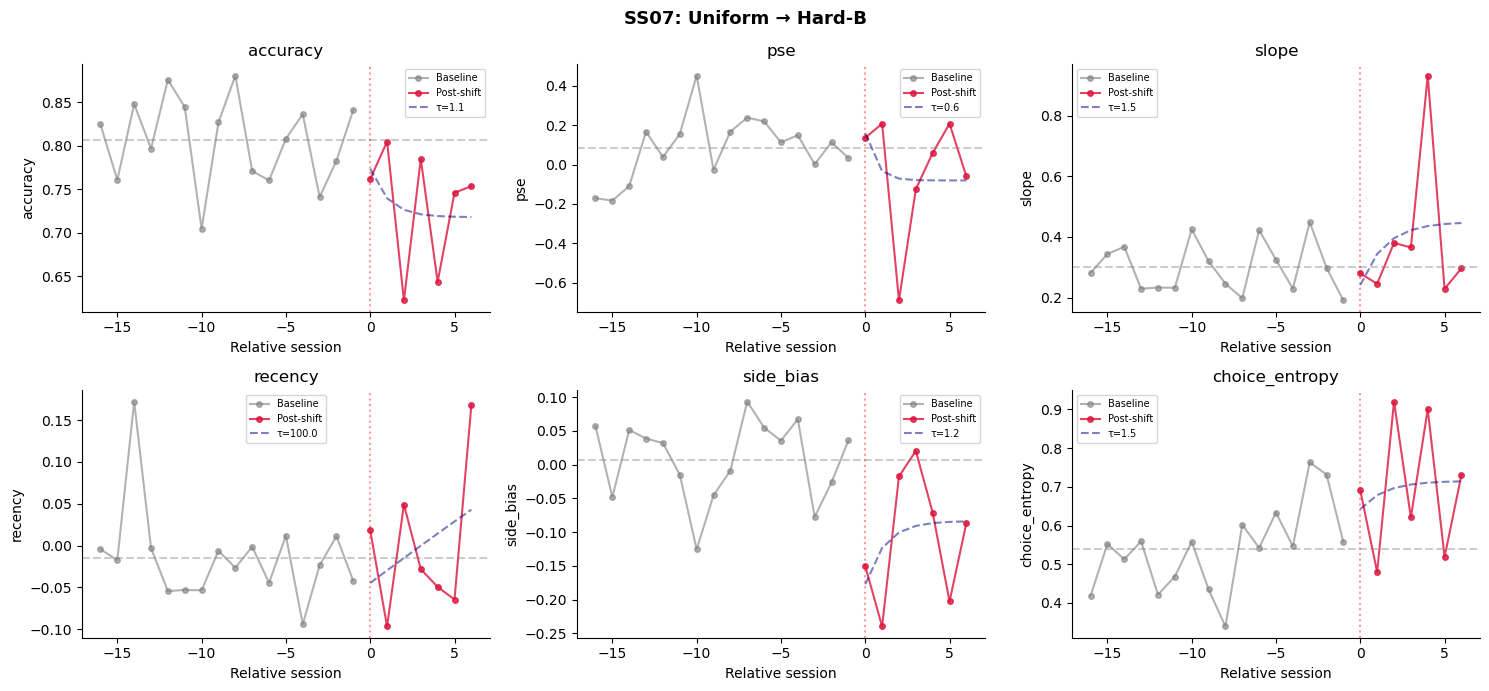

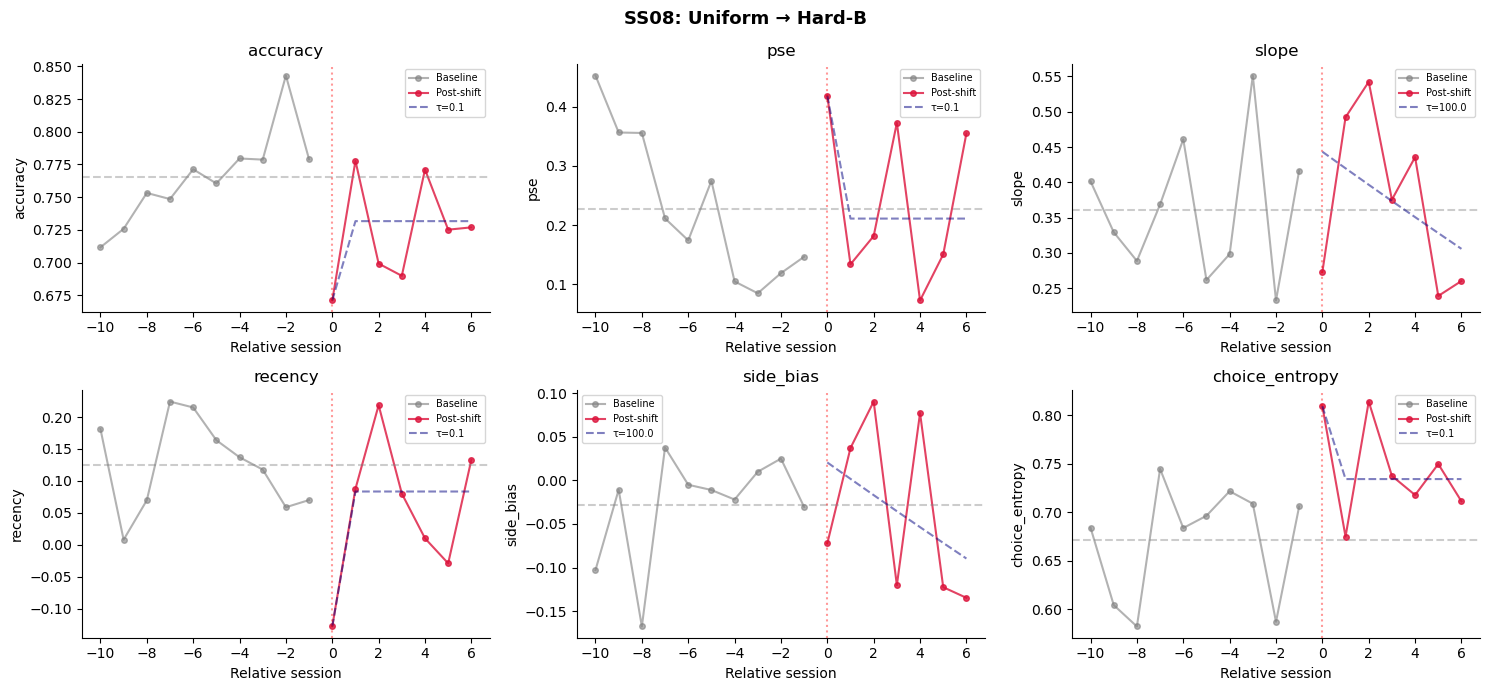

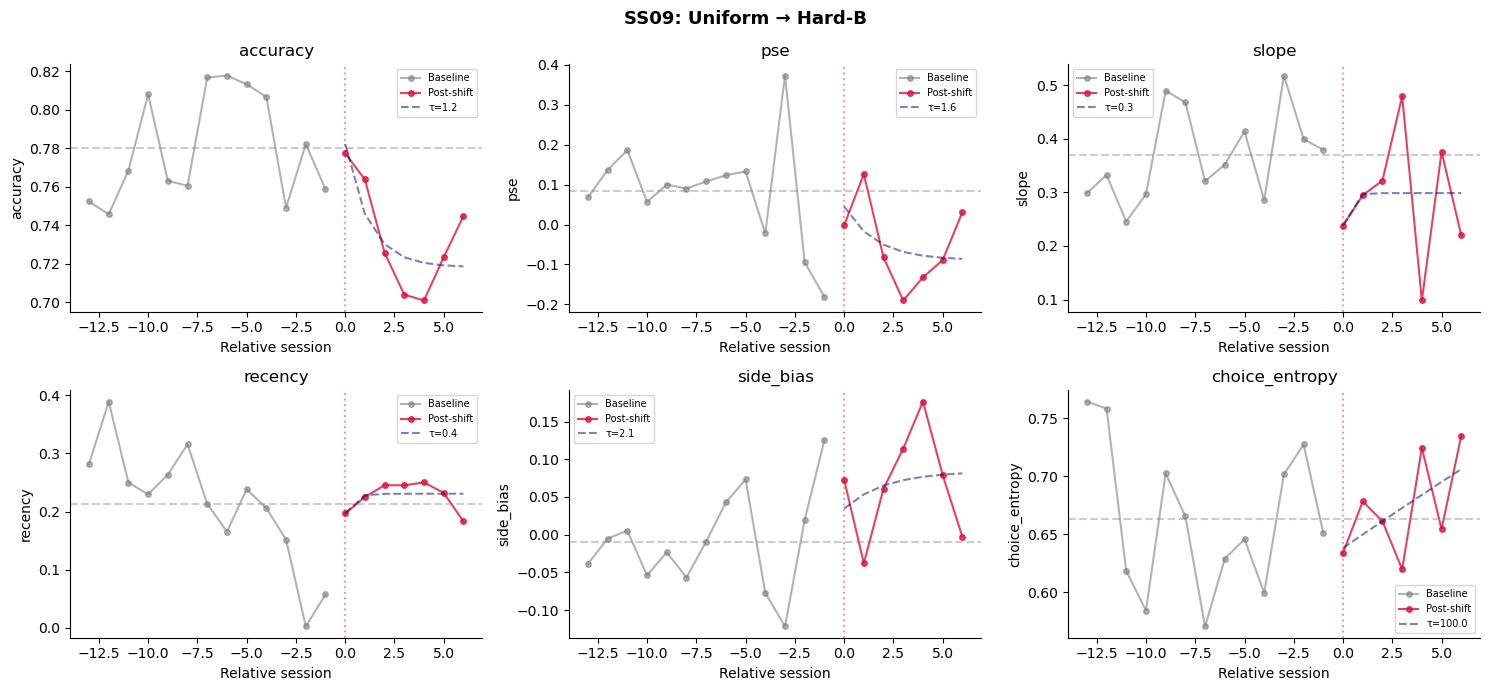

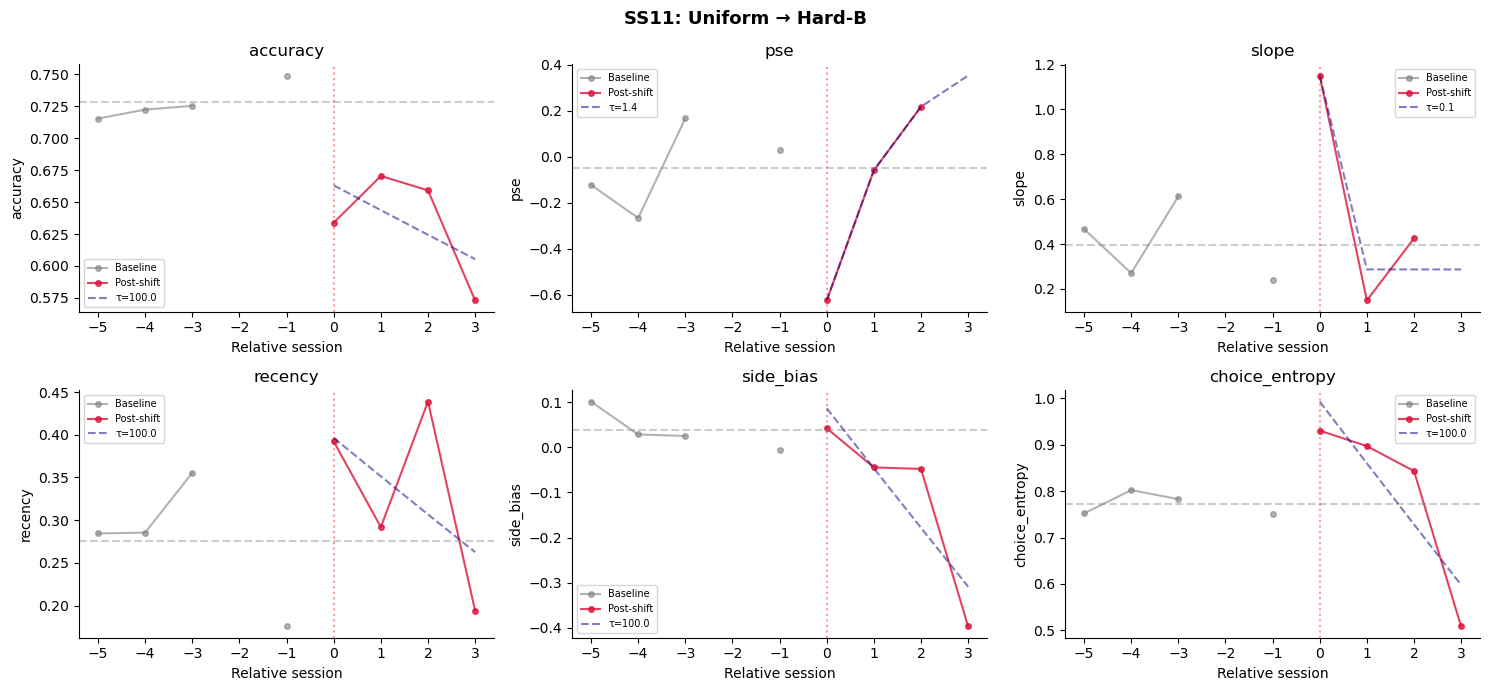

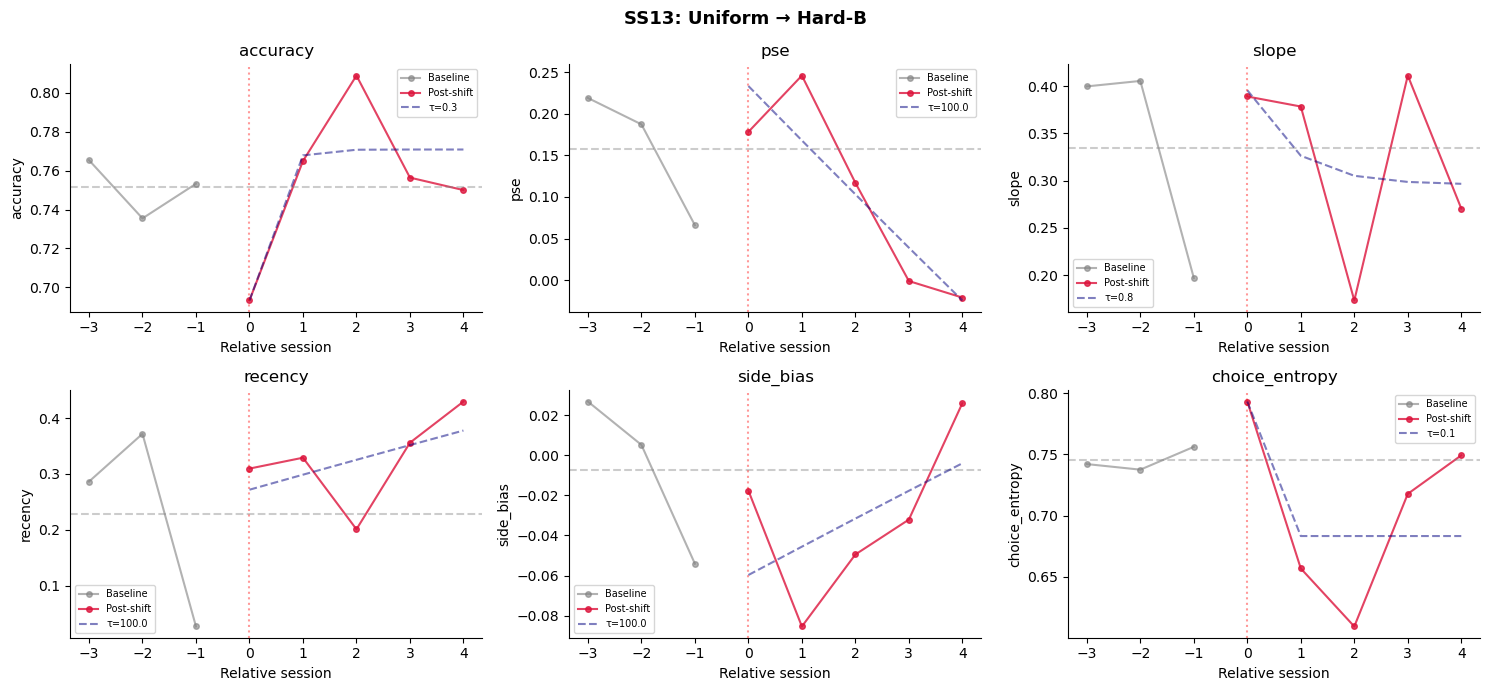

In [6]:
for aid, res in per_animal_results.items():
    traj = res['trajectory']
    n_stats = len(TRACK_STATS)
    n_cols = min(3, n_stats)
    n_rows = int(np.ceil(n_stats / n_cols))

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 3.5 * n_rows))
    axes_flat = np.array(axes).flatten()

    for ax, stat in zip(axes_flat, TRACK_STATS):
        if stat not in traj.columns:
            ax.set_visible(False)
            continue

        bl = traj[traj['phase'] == 'baseline']
        post = traj[traj['phase'] == 'post']

        ax.plot(bl['relative_session'], bl[stat], 'o-',
                color='grey', alpha=0.6, markersize=4, label='Baseline')
        ax.plot(post['relative_session'], post[stat], 'o-',
                color=COLOURS.get('shift', 'crimson'), alpha=0.8,
                markersize=4, label='Post-shift')

        # Baseline mean line
        bl_mean_col = f'baseline_{stat}_mean'
        if bl_mean_col in traj.columns:
            bl_mean = traj[bl_mean_col].iloc[0]
            if not np.isnan(bl_mean):
                ax.axhline(bl_mean, color='grey', ls='--', alpha=0.4)

        # Recovery fit
        rec = res['recovery'].get(stat, {})
        if rec.get('converged', False) and len(rec.get('fitted_values', [])) > 0:
            ax.plot(rec['relative_sessions'], rec['fitted_values'],
                    '--', color='navy', alpha=0.5, lw=1.5,
                    label=f'τ={rec["tau"]:.1f}')

        ax.axvline(0, color='red', ls=':', alpha=0.4)
        ax.set_xlabel('Relative session')
        ax.set_ylabel(stat)
        ax.set_title(stat)
        ax.legend(fontsize=7)

    for j in range(n_stats, len(axes_flat)):
        axes_flat[j].set_visible(False)

    shift_desc = res['shift']['details']
    fig.suptitle(f"{aid}: {shift_desc.get('before', '?')} → {shift_desc.get('after', '?')}",
                 fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

## 5. Phase Comparisons

In [7]:
for aid, res in per_animal_results.items():
    print(f"\n{aid}: {res['shift']['details']}")

    print("\n  Baseline vs Early Post:")
    df = res['comp_early']
    for _, row in df.iterrows():
        sig = '*' if row['p_value'] < 0.05 else ' '
        print(f"    {row['stat']:>20s}: {row['a_mean']:.3f} → {row['b_mean']:.3f}  "
              f"p={row['p_value']:.3g} {sig}  d={row['cliffs_delta']:.2f}")

    print("\n  Baseline vs Late Post:")
    df = res['comp_late']
    for _, row in df.iterrows():
        sig = '*' if row['p_value'] < 0.05 else ' '
        print(f"    {row['stat']:>20s}: {row['a_mean']:.3f} → {row['b_mean']:.3f}  "
              f"p={row['p_value']:.3g} {sig}  d={row['cliffs_delta']:.2f}")


SS01: {'before': 'Uniform', 'after': 'Hard-B'}

  Baseline vs Early Post:
                accuracy: 0.727 → 0.562  p=0.000666 *  d=1.00
                     pse: 0.101 → 0.584  p=0.00699 *  d=-1.00
                   slope: 0.530 → 0.174  p=0.028 *  d=0.87
                 recency: 0.063 → 0.026  p=0.594    d=0.20
               side_bias: -0.048 → -0.370  p=0.000666 *  d=1.00
          choice_entropy: 0.774 → 0.513  p=0.000666 *  d=1.00

  Baseline vs Late Post:
                accuracy: 0.727 → 0.549  p=0.000666 *  d=1.00
                     pse: 0.101 → 0.811  p=nan    d=-1.00
                   slope: 0.530 → 1.074  p=nan    d=0.00
                 recency: 0.063 → 0.040  p=0.679    d=0.16
               side_bias: -0.048 → -0.349  p=0.000666 *  d=1.00
          choice_entropy: 0.774 → 0.574  p=0.165    d=0.48

SS04: {'before': 'Uniform', 'after': 'Hard-B'}

  Baseline vs Early Post:
                accuracy: 0.796 → 0.786  p=0.65    d=0.15
                     pse: 0.139 → -0.15

## 6. Convergence Summary Table

In [8]:
# Build summary across animals
summary_rows = []

for aid, res in per_animal_results.items():
    row = {
        'animal_id': aid,
        'shift_type': res['shift']['details'].get('after', '?'),
        'n_baseline': len(res['baseline']),
        'n_post': len(res['post']),
        'accuracy_drop': res['acc_drop']['value'],
        'pse_shift': res['pse_shift']['value'],
    }

    conv = res['convergence']
    for _, crow in conv.iterrows():
        stat = crow['stat']
        row[f'{stat}_tau'] = crow['tau']
        row[f'{stat}_ttc'] = crow['sessions_to_criterion']
        row[f'{stat}_r2'] = crow['r_squared']

    n_updating = res['labels'].count('updating')
    row['n_updating_sessions'] = n_updating
    row['frac_updating'] = n_updating / len(res['labels']) if res['labels'] else np.nan

    summary_rows.append(row)

summary_df = pd.DataFrame(summary_rows)
print("Convergence Summary:")
display_cols = ['animal_id', 'shift_type', 'n_baseline', 'n_post',
                'accuracy_drop', 'accuracy_tau', 'accuracy_ttc',
                'pse_shift', 'n_updating_sessions', 'frac_updating']
display_cols = [c for c in display_cols if c in summary_df.columns]
print(summary_df[display_cols].to_string(index=False, float_format='{:.3f}'.format))

Convergence Summary:
animal_id shift_type  n_baseline  n_post  accuracy_drop  accuracy_tau  accuracy_ttc  pse_shift  n_updating_sessions  frac_updating
     SS01     Hard-B          11       7          0.150         1.160           NaN      0.483                    7          1.000
     SS04     Hard-B          23       7          0.017         4.918         1.000     -0.332                    2          0.286
     SS05     Hard-B           9       7          0.130         1.125           NaN      0.525                    7          1.000
     SS06     Hard-B          12       7          0.079         1.614         4.000      0.038                    7          1.000
     SS07     Hard-B          16       7          0.077         1.063         0.000     -0.201                    3          0.429
     SS08     Hard-B          10       7          0.049         0.100         1.000      0.017                    5          0.714
     SS09     Hard-B          13       7          0.025       

## 7. Group-Level Trajectories

Aggregate shift-aligned trajectories across animals.

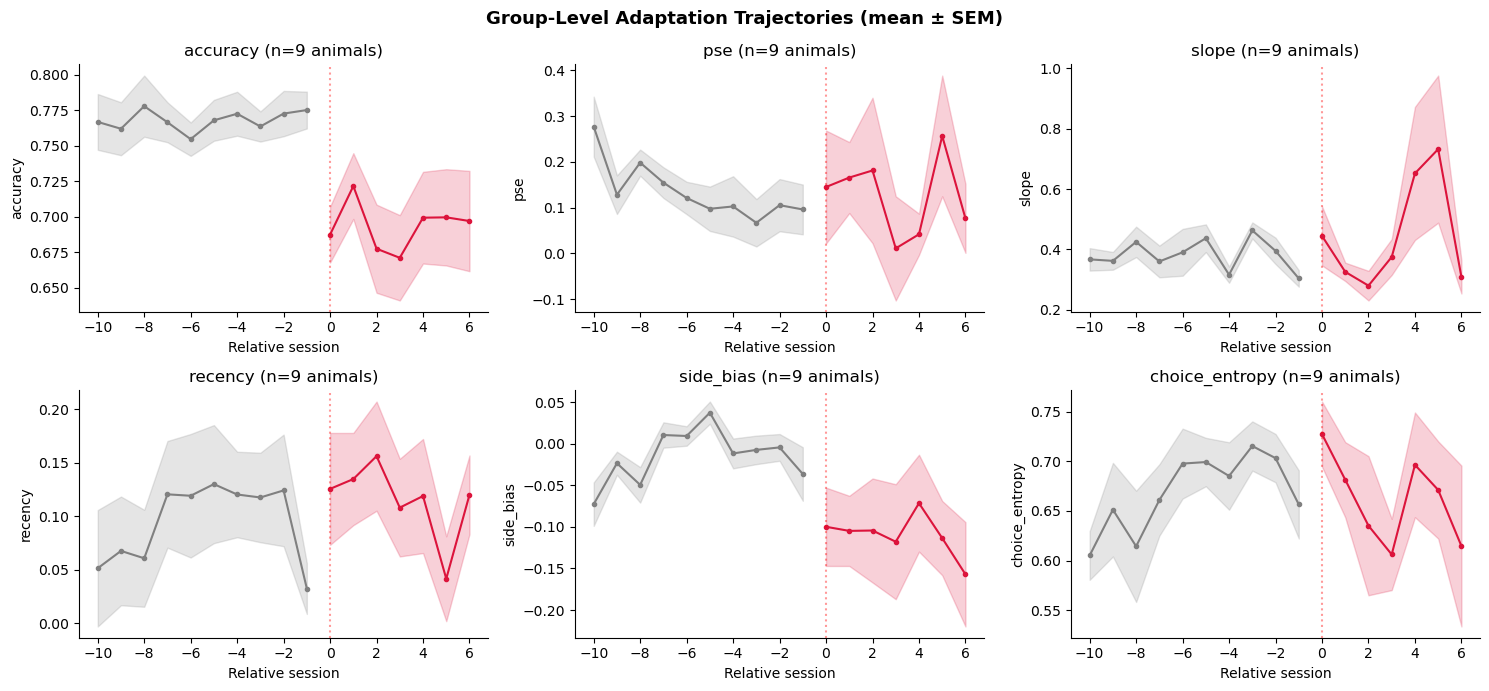

In [9]:
# Collect all trajectories with animal_id
all_trajectories = []
for aid, res in per_animal_results.items():
    traj = res['trajectory'].copy()
    traj['animal_id'] = aid
    all_trajectories.append(traj)

if all_trajectories:
    agg = aggregate_trajectories(all_trajectories, stats=TRACK_STATS,
                                  session_range=(-10, 20))

    n_stats = len(TRACK_STATS)
    n_cols = min(3, n_stats)
    n_rows = int(np.ceil(n_stats / n_cols))

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 3.5 * n_rows))
    axes_flat = np.array(axes).flatten()

    for ax, stat in zip(axes_flat, TRACK_STATS):
        sub = agg[agg['stat'] == stat]
        if len(sub) == 0:
            ax.set_visible(False)
            continue

        pre = sub[sub['relative_session'] < 0]
        post = sub[sub['relative_session'] >= 0]

        ax.fill_between(pre['relative_session'],
                         pre['mean'] - pre['sem'],
                         pre['mean'] + pre['sem'],
                         color='grey', alpha=0.2)
        ax.plot(pre['relative_session'], pre['mean'],
                'o-', color='grey', markersize=3)

        ax.fill_between(post['relative_session'],
                         post['mean'] - post['sem'],
                         post['mean'] + post['sem'],
                         color=COLOURS.get('shift', 'crimson'), alpha=0.2)
        ax.plot(post['relative_session'], post['mean'],
                'o-', color=COLOURS.get('shift', 'crimson'), markersize=3)

        ax.axvline(0, color='red', ls=':', alpha=0.4)
        ax.set_xlabel('Relative session')
        ax.set_ylabel(stat)
        ax.set_title(f'{stat} (n={int(sub["n_animals"].max())} animals)')

    for j in range(n_stats, len(axes_flat)):
        axes_flat[j].set_visible(False)

    fig.suptitle('Group-Level Adaptation Trajectories (mean ± SEM)',
                 fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()
else:
    print('No animals with shift data to aggregate.')

## 8. Update Matrix Evolution Across the Shift

How does the update matrix change from expert baseline through
early post-shift to late post-shift?

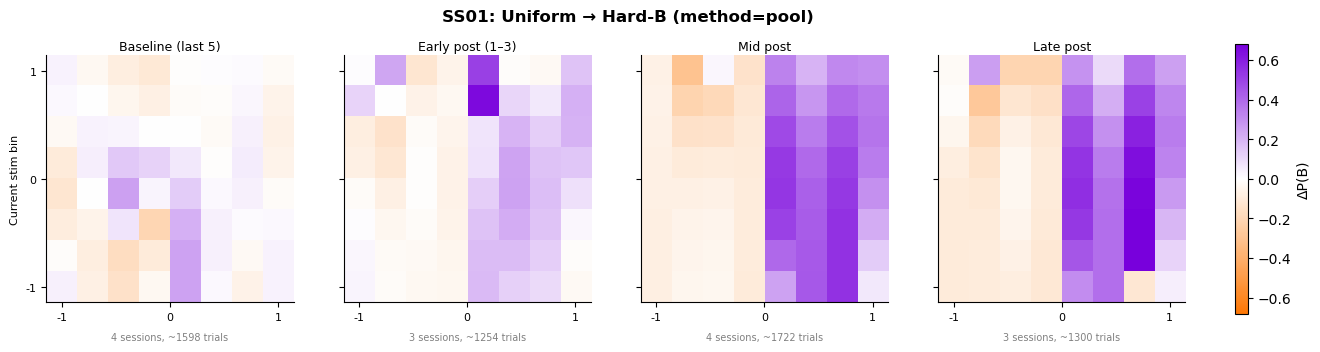

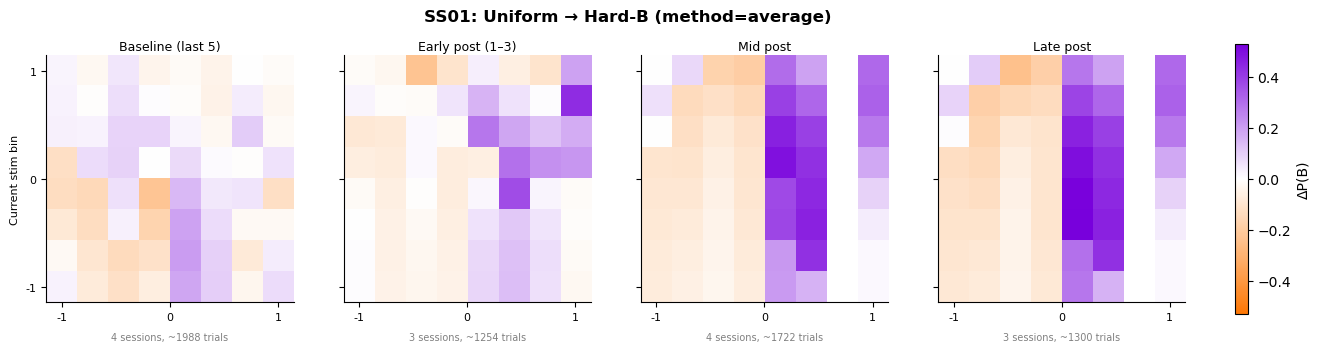

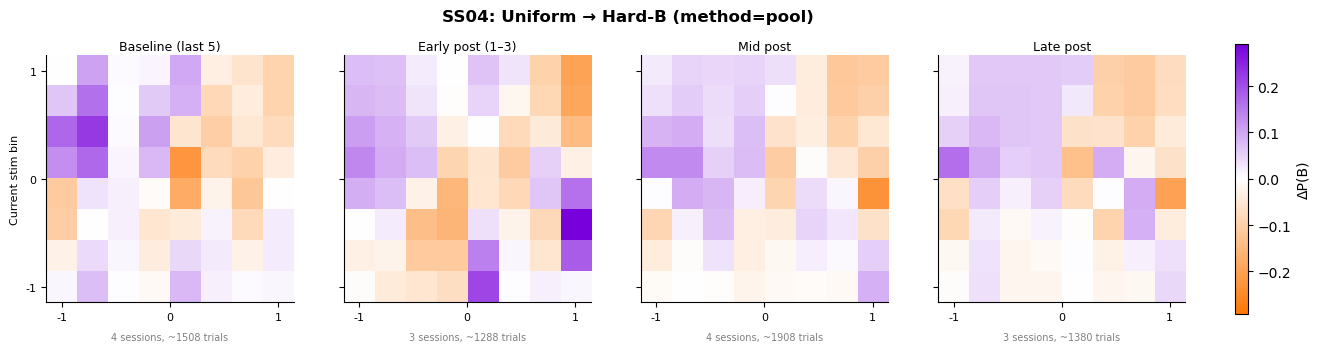

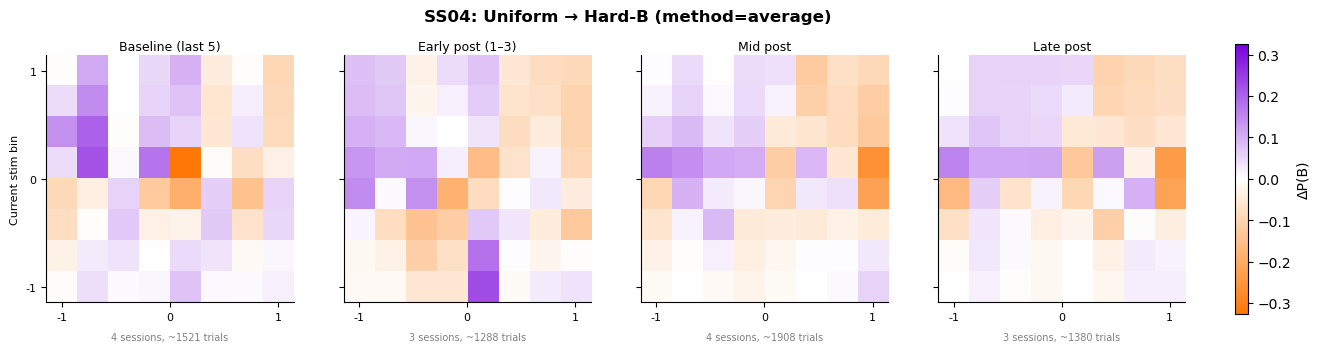

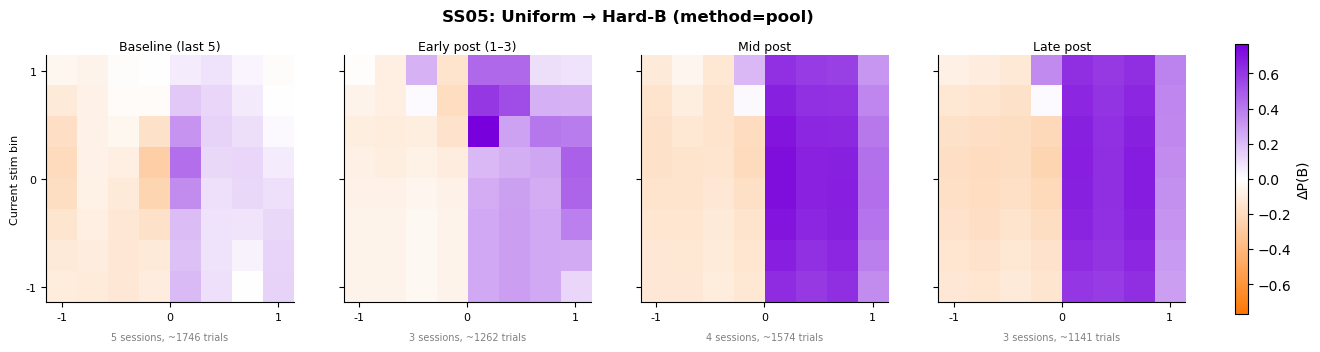

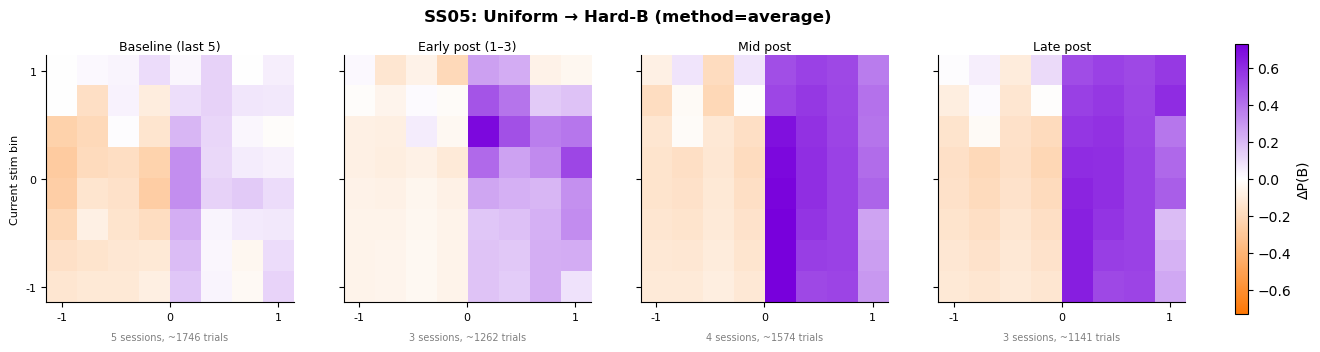

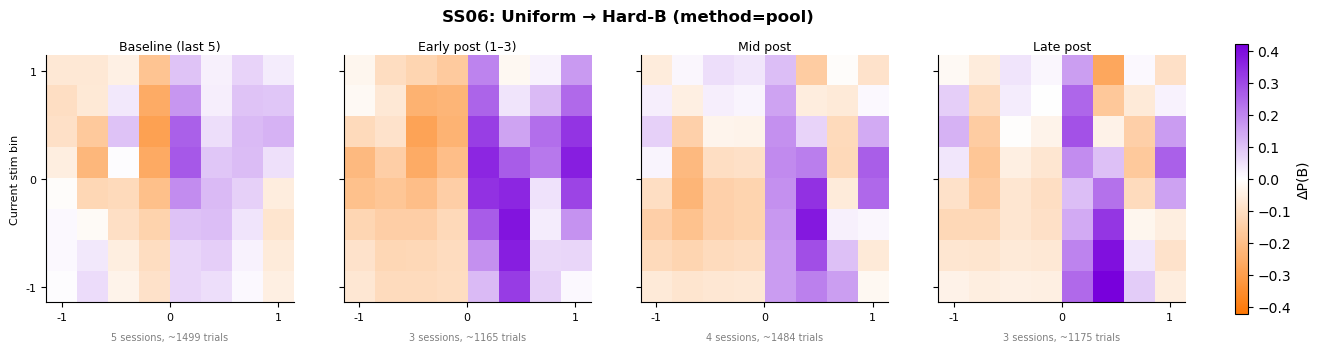

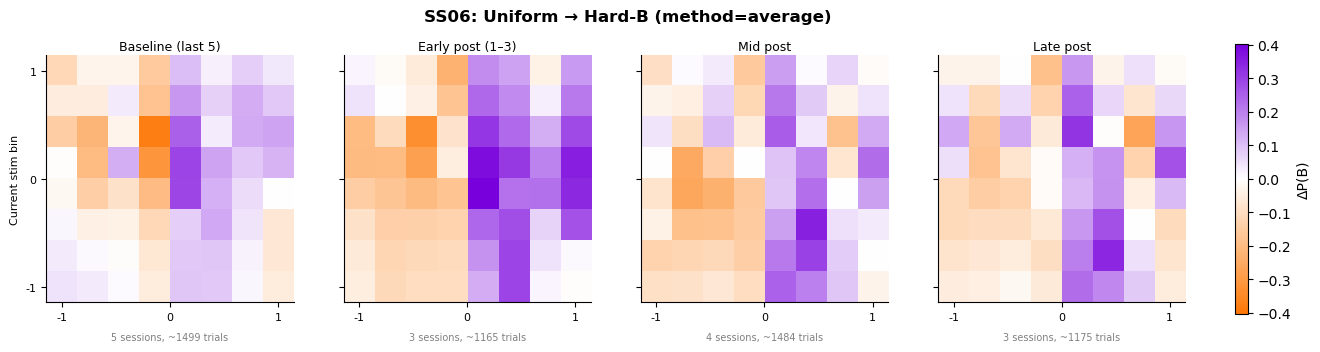

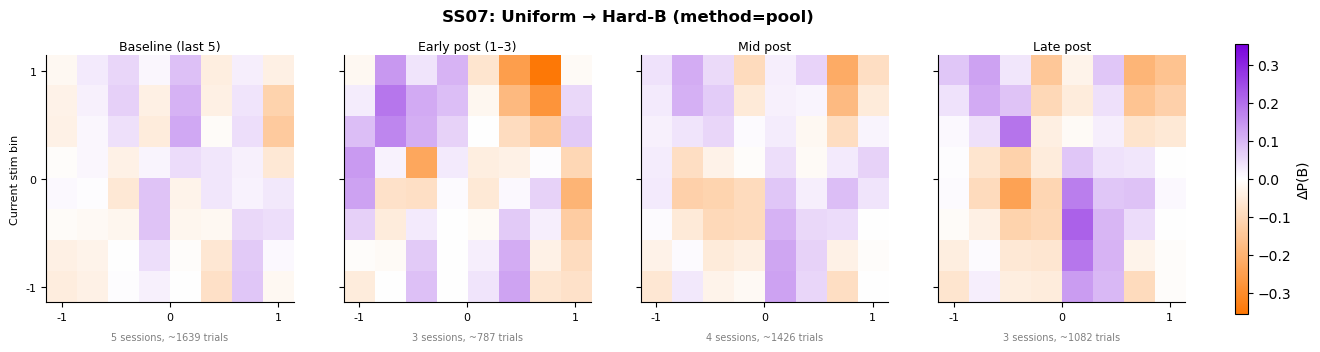

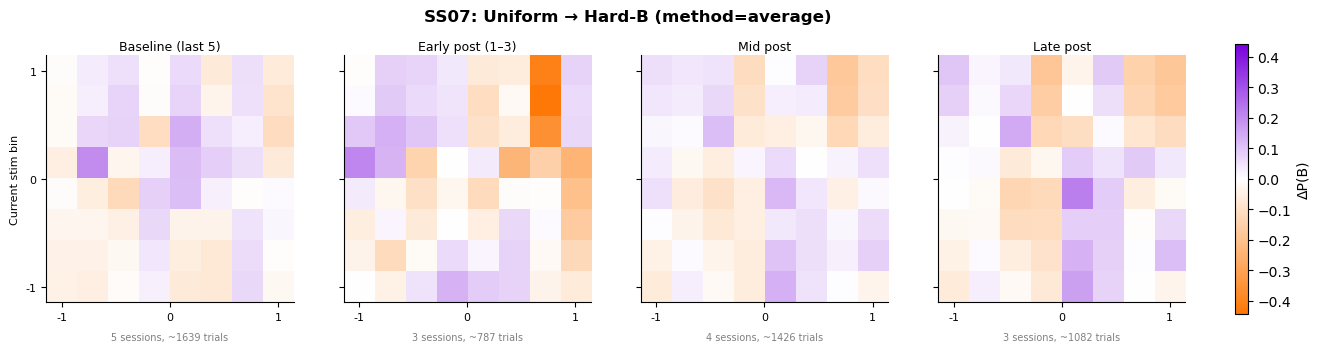

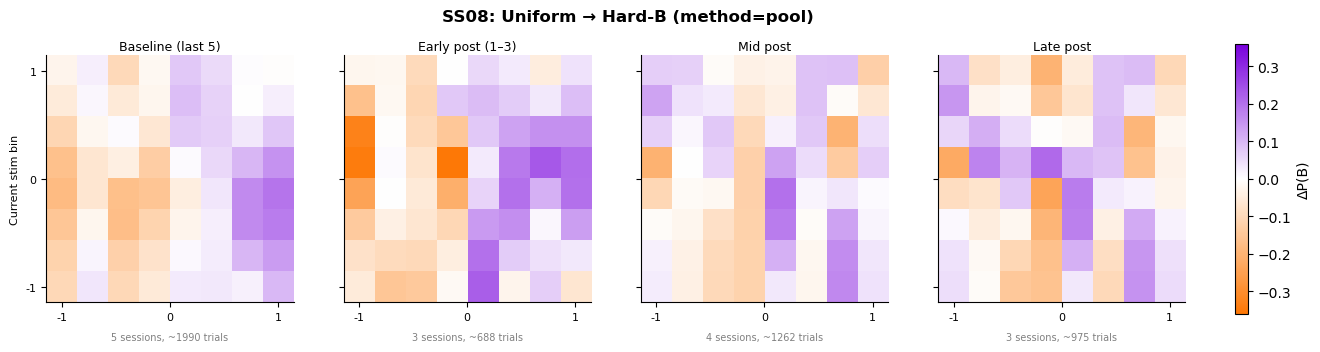

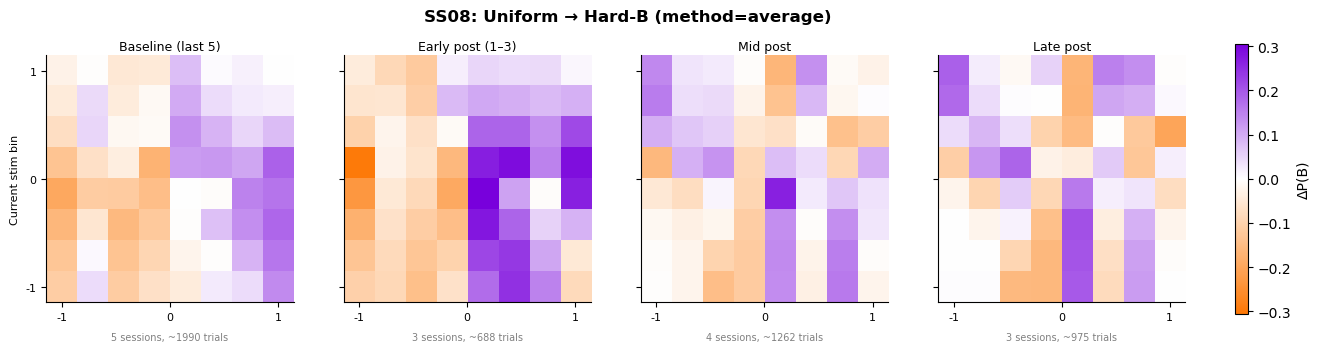

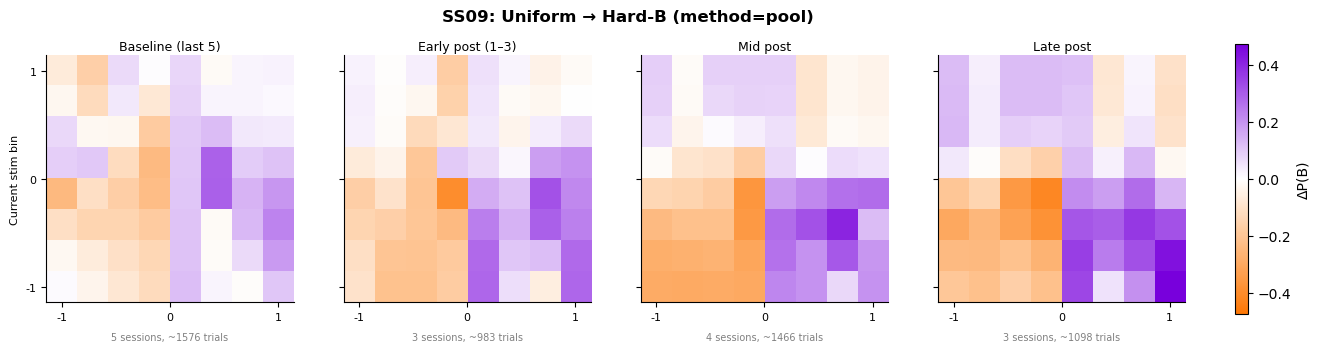

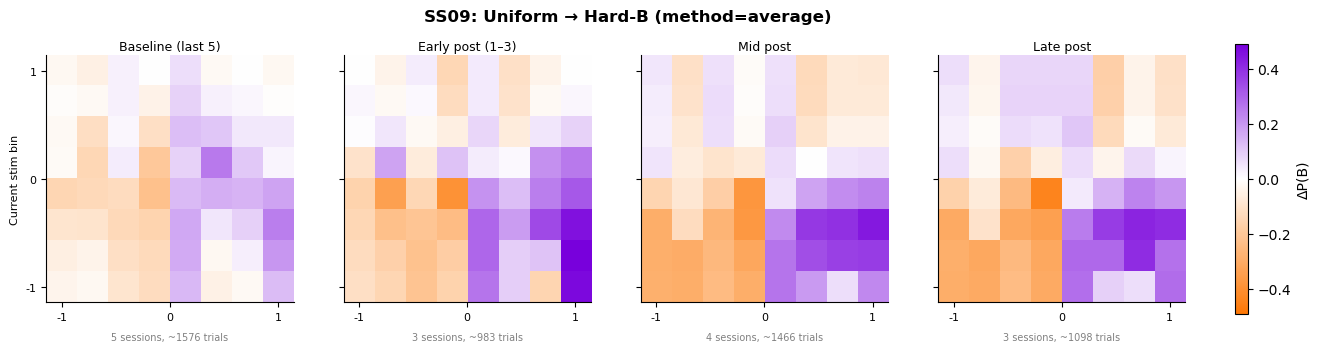

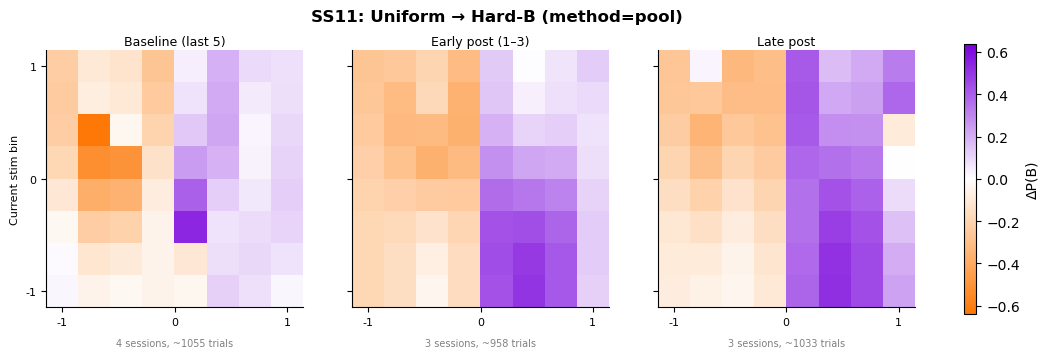

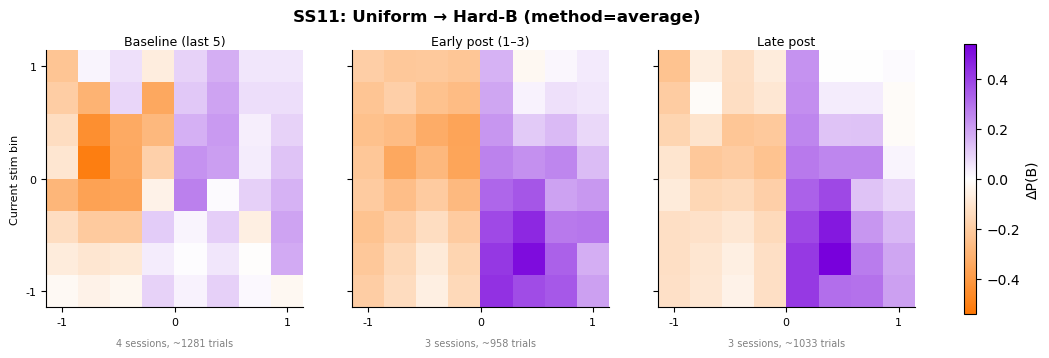

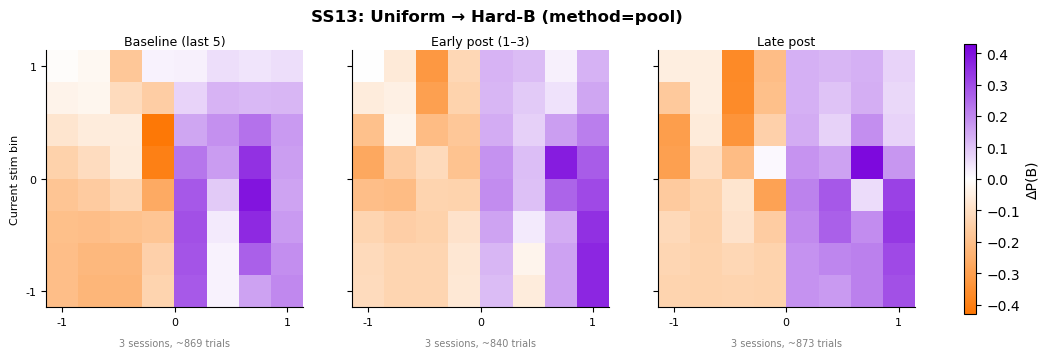

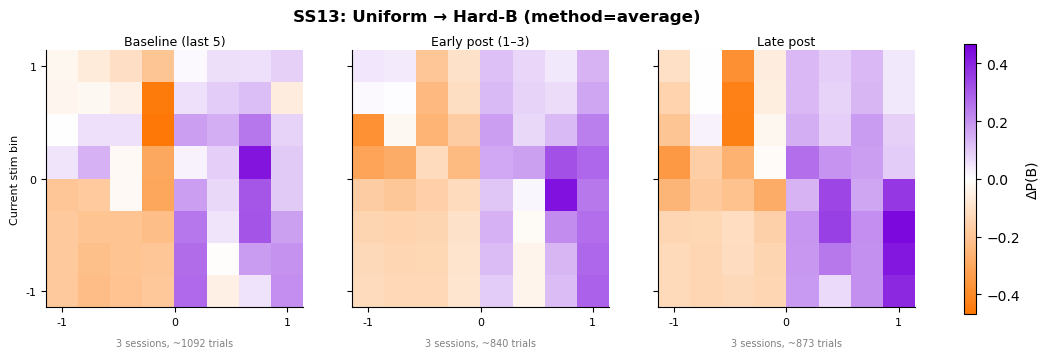

In [10]:
for aid, res in per_animal_results.items():
    baseline = res['baseline']
    post = res['post']
    shift_desc = res['shift']['details']
    title_base = (f"{aid}: {shift_desc.get('before', '?')} → "
                  f"{shift_desc.get('after', '?')}")

    # Define phases
    phase_sessions = {
        'Baseline (last 5)': baseline[-5:] if len(baseline) >= 5 else baseline,
        'Early post (1–3)':  post[:3],
    }
    if len(post) > 6:
        phase_sessions['Mid post'] = post[3:min(8, len(post))]
    if len(post) >= 3:
        phase_sessions['Late post'] = post[-3:]

    # Remove empty phases
    phase_sessions = {k: v for k, v in phase_sessions.items() if len(v) > 0}

    for method in ['pool', 'average']:
        phases = {}
        annotations = {}
        for label, sessions in phase_sessions.items():
            um, _, info = compute_update_matrix_from_sessions(
                sessions, method=method,
            )
            phases[label] = um
            n_s = info.get('n_sessions', len(sessions))
            n_t = info.get('n_trials_pooled', sum(
                s.trials.valid_mask.sum() for s in sessions))
            annotations[label] = f'{n_s} sessions, ~{n_t} trials'

        fig, axes = plot_phase_update_matrices(
            phases,
            suptitle=f'{title_base} (method={method})',
            annotations=annotations,
        )
        plt.show()

## 8b. Psychometric Comparison Across the Shift

Overlay pooled psychometric curves from baseline and post-shift phases
on the same axes. Look for:
- PSE shift (curve moves left/right)
- Slope change (curve becomes shallower during re-learning)
- Lapse rate changes (asymmetric lapses under asymmetric distributions)

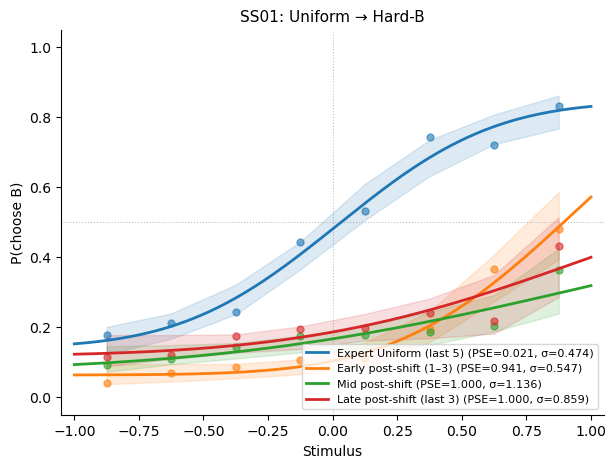

                           Phase       PSE         σ  lapse_lo  lapse_hi  n_trials
         Expert Uniform (last 5)     0.021     0.474     0.141     0.155      1598
          Early post-shift (1–3)     0.941     0.547     0.063     0.000      1254
                  Mid post-shift     1.000     1.136     0.074     0.436      1722
        Late post-shift (last 3)     1.000     0.859     0.117     0.318      1300



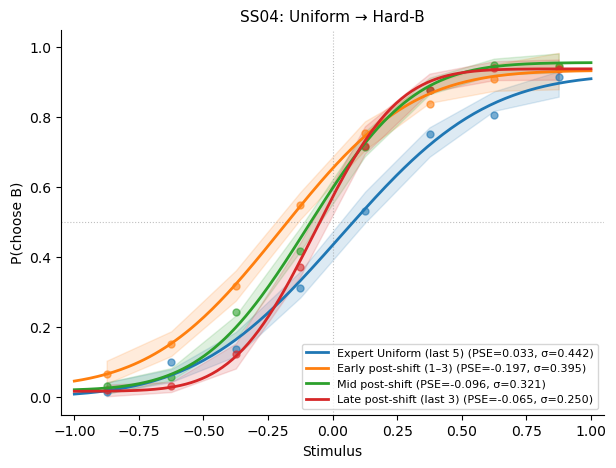

                           Phase       PSE         σ  lapse_lo  lapse_hi  n_trials
         Expert Uniform (last 5)     0.033     0.442     0.000     0.077      1508
          Early post-shift (1–3)    -0.197     0.395     0.027     0.066      1288
                  Mid post-shift    -0.096     0.321     0.019     0.044      1908
        Late post-shift (last 3)    -0.065     0.250     0.017     0.062      1380



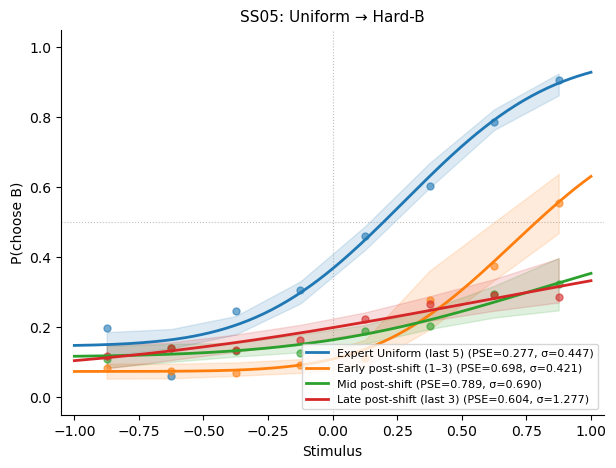

                           Phase       PSE         σ  lapse_lo  lapse_hi  n_trials
         Expert Uniform (last 5)     0.277     0.447     0.146     0.028      1746
          Early post-shift (1–3)     0.698     0.421     0.074     0.197      1262
                  Mid post-shift     0.789     0.690     0.115     0.500      1574
        Late post-shift (last 3)     0.604     1.277     0.058     0.500      1141



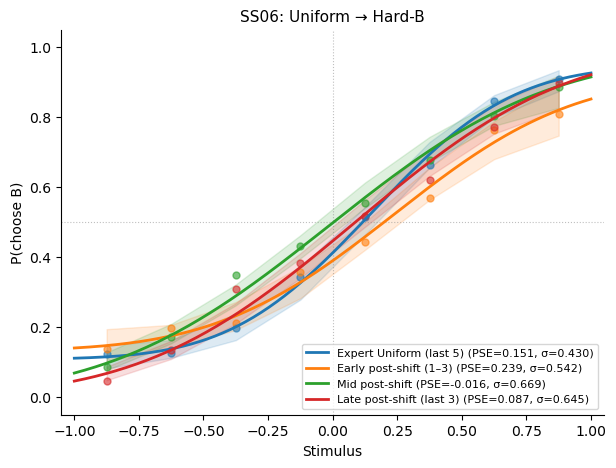

                           Phase       PSE         σ  lapse_lo  lapse_hi  n_trials
         Expert Uniform (last 5)     0.151     0.430     0.108     0.053      1499
          Early post-shift (1–3)     0.239     0.542     0.132     0.085      1165
                  Mid post-shift    -0.016     0.669     0.000     0.022      1484
        Late post-shift (last 3)     0.087     0.645     0.000     0.000      1175



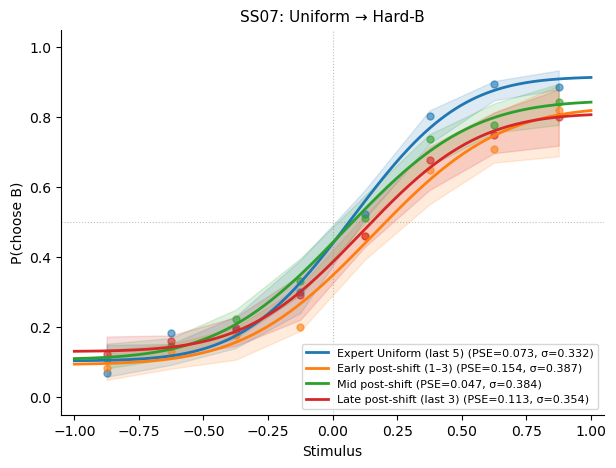

                           Phase       PSE         σ  lapse_lo  lapse_hi  n_trials
         Expert Uniform (last 5)     0.073     0.332     0.104     0.084      1639
          Early post-shift (1–3)     0.154     0.387     0.094     0.170       787
                  Mid post-shift     0.047     0.384     0.108     0.152      1426
        Late post-shift (last 3)     0.113     0.354     0.131     0.189      1082



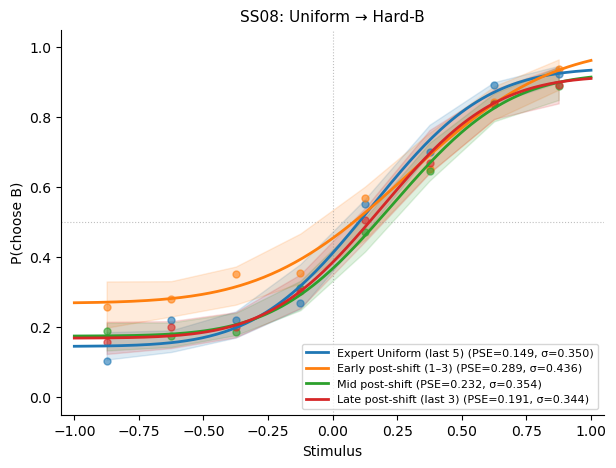

                           Phase       PSE         σ  lapse_lo  lapse_hi  n_trials
         Expert Uniform (last 5)     0.149     0.350     0.145     0.060      1990
          Early post-shift (1–3)     0.289     0.436     0.269     0.000       688
                  Mid post-shift     0.232     0.354     0.175     0.074      1262
        Late post-shift (last 3)     0.191     0.344     0.169     0.082       975



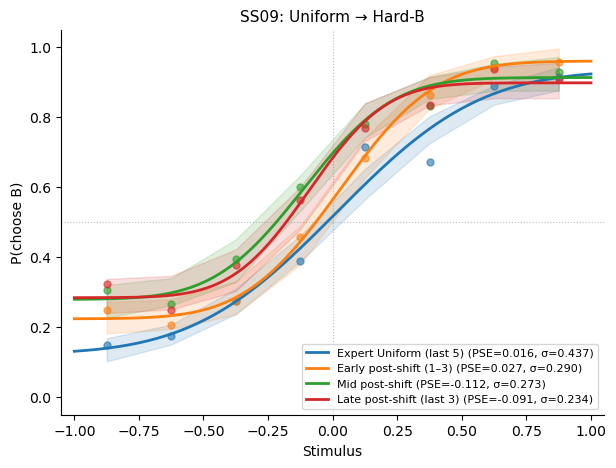

                           Phase       PSE         σ  lapse_lo  lapse_hi  n_trials
         Expert Uniform (last 5)     0.016     0.437     0.123     0.067      1576
          Early post-shift (1–3)     0.027     0.290     0.224     0.040       983
                  Mid post-shift    -0.112     0.273     0.279     0.087      1466
        Late post-shift (last 3)    -0.091     0.234     0.284     0.102      1098



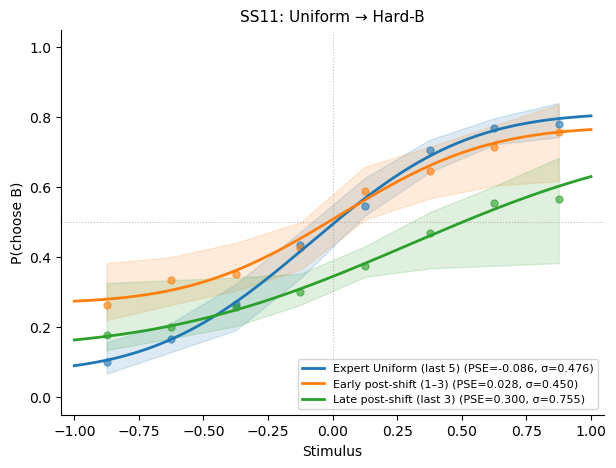

                           Phase       PSE         σ  lapse_lo  lapse_hi  n_trials
         Expert Uniform (last 5)    -0.086     0.476     0.070     0.188      1055
          Early post-shift (1–3)     0.028     0.450     0.269     0.227       958
        Late post-shift (last 3)     0.300     0.755     0.138     0.264      1033



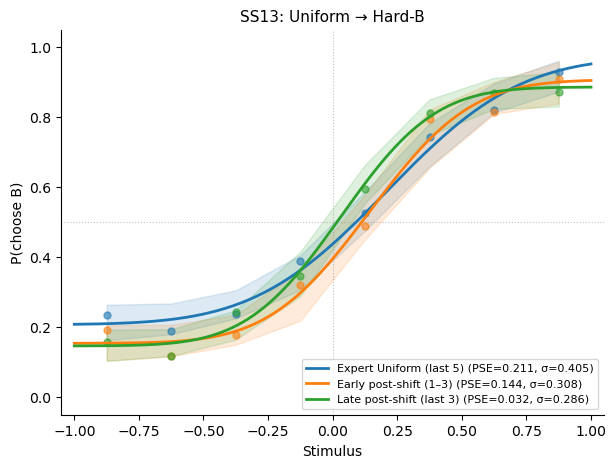

                           Phase       PSE         σ  lapse_lo  lapse_hi  n_trials
         Expert Uniform (last 5)     0.211     0.405     0.207     0.028       869
          Early post-shift (1–3)     0.144     0.308     0.154     0.093       840
        Late post-shift (last 3)     0.032     0.286     0.147     0.114       873



In [11]:
for aid, res in per_animal_results.items():
    baseline = res['baseline']
    post = res['post']
    shift_desc = res['shift']['details']

    groups = {'Expert Uniform (last 5)': baseline[-5:]}
    if len(post) >= 3:
        groups['Early post-shift (1–3)'] = post[:3]
    if len(post) > 6:
        groups['Mid post-shift'] = post[3:min(8, len(post))]
    if len(post) >= 3:
        groups['Late post-shift (last 3)'] = post[-3:]

    fig, ax, infos = plot_psychometric_overlay(
        groups,
        mode='pooled',
        n_bootstrap=200,
        show_ci=True,
        title=(f"{aid}: {shift_desc.get('before', '?')} → "
               f"{shift_desc.get('after', '?')}"),
    )
    plt.show()

    # Print parameter table
    print(f"  {'Phase':>30s}  {'PSE':>8s}  {'σ':>8s}  {'lapse_lo':>8s}  {'lapse_hi':>8s}  {'n_trials':>8s}")
    for label, fit_info in infos.items():
        if fit_info.get('success', False):
            print(f"  {label:>30s}  {fit_info['mu']:8.3f}  {fit_info['sigma']:8.3f}  "
                  f"{fit_info['lapse_low']:8.3f}  {fit_info['lapse_high']:8.3f}  "
                  f"{fit_info.get('n_trials', '?'):>8}")
    print()

## 8c. Connection to Model Predictions

Compare the observed post-shift changes to the predictions generated
in notebooks 0b (Section 7) and 1b (Section 7).

**From 0b:** BE and SC models predict specific stat trajectories and
update matrix patterns at each phase. Do the real data match one
model better than the other?

**From 1b:** Sensitivity analysis predicted which stats should change
most post-shift and in which direction. Do the observed changes match?

In [12]:
# Load model predictions if available
# (These would come from running notebook 0b Section 7)
predictions_path = Path('../results/shift_predictions.pkl')
if predictions_path.exists():
    import pickle
    with open(predictions_path, 'rb') as f:
        model_predictions = pickle.load(f)
    print('Loaded model predictions from 0b')
    # TODO: overlay model predictions on real data trajectories
    # This requires saving be_results/sc_results from 0b Section 7
else:
    print('No model predictions found — run notebook 0b Section 7 first')
    print(f'Expected at: {predictions_path}')

# ── Qualitative comparison table ─────────────────────────────────────────
print('\n=== Observed vs Predicted Changes ===')
print('(Fill in after running 0b and 1b)\n')
print(f'{"Stat":>15s}  {"Observed":>12s}  {"BE pred":>12s}  {"SC pred":>12s}  {"Match":>8s}')
print('-' * 68)

# Compute observed changes (early post vs baseline mean)
for stat in TRACK_STATS:
    obs_changes = []
    for aid, res in per_animal_results.items():
        traj = res['trajectory']
        bl_mean = traj[f'baseline_{stat}_mean'].iloc[0]
        early = traj[(traj['phase'] == 'post')][stat].head(3).mean()
        if not np.isnan(bl_mean) and not np.isnan(early):
            obs_changes.append(early - bl_mean)

    if obs_changes:
        mean_change = np.mean(obs_changes)
        direction = '↑' if mean_change > 0 else '↓'
        print(f'{stat:>15s}  {direction} {abs(mean_change):.3f}  '
              f'{"(run 0b)":>12s}  {"(run 0b)":>12s}  {"—":>8s}')
    else:
        print(f'{stat:>15s}  {"no data":>12s}')

No model predictions found — run notebook 0b Section 7 first
Expected at: ../results/shift_predictions.pkl

=== Observed vs Predicted Changes ===
(Fill in after running 0b and 1b)

           Stat      Observed       BE pred       SC pred     Match
--------------------------------------------------------------------
       accuracy  ↓ 0.066      (run 0b)      (run 0b)         —
            pse  ↑ 0.042      (run 0b)      (run 0b)         —
          slope  ↓ 0.030      (run 0b)      (run 0b)         —
        recency  ↑ 0.009      (run 0b)      (run 0b)         —
      side_bias  ↓ 0.091      (run 0b)      (run 0b)         —
 choice_entropy  ↓ 0.002      (run 0b)      (run 0b)         —


## 9. Save Results

In [13]:
# import pickle

# results_dir = Path('../results/adaptation')
# results_dir.mkdir(parents=True, exist_ok=True)

# # Save summary table
# summary_df.to_csv(results_dir / 'adaptation_summary.csv', index=False)

# # Save per-animal results (excluding session objects)
# save_results = {}
# for aid, res in per_animal_results.items():
#     save_results[aid] = {
#         'shift': res['shift'],
#         'trajectory': res['trajectory'],
#         'convergence': res['convergence'],
#         'comp_early': res['comp_early'],
#         'comp_late': res['comp_late'],
#         'acc_drop': res['acc_drop'],
#         'pse_shift': res['pse_shift'],
#         'labels': res['labels'],
#     }

# with open(results_dir / 'adaptation_results.pkl', 'wb') as f:
#     pickle.dump(save_results, f)

# print(f"Saved to {results_dir}/")

## Interpretation

**Accuracy drop**: Immediate effect of the distribution shift. Larger drops
indicate the old statistical model was more inadequate for the new distribution.

**Recovery τ**: How many sessions to re-adapt. Compare across transition types:
Uniform→Hard-A (novel) should be slower than Hard-B→Hard-A (familiar return).

**Psychometric changes**: PSE shift indicates bias change; slope change indicates
discrimination difficulty. Asymmetric lapse rates under Hard-A/B are expected
(the overrepresented side has more near-boundary trials → harder discrimination).

**Update matrix evolution**: The baseline expert pattern (e.g., BE win-stay stripe)
should degrade early post-shift and recover. If the pattern changes qualitatively
(not just degrades), this suggests the animal's serial dependence strategy itself
is changing during adaptation.

**State classification**: Sessions classified as 'updating' are candidates
for when PPC inactivation should have maximum effect (Aim 2 prediction).

**Connection to model predictions**: Stats where the observed direction of change
matches one model but not the other provide evidence for that model's mechanism.
This complements the update-matrix-based classification from 3a/3c.

**Next steps**:
- 4b: Fit BE/SC models to post-shift data to track parameter trajectories
- 5: Use SLDS on these features for automated learning phase assignment
- 6a: Generate opto predictions from the adaptation dynamics